In [1]:
# ===============================
# STEP 1: Import Libraries & Load Data
# ===============================

# Basic Data Handling
import pandas as pd
import numpy as np

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Load Dataset
df=pd.read_excel(r"C:\Users\ak32a\Downloads\Anal-ysts\LTF Challenge data with dictionary.xlsx", sheet_name="TrainData")

In [4]:
# View structure
print("Data shape:", df.shape)
df.head()

Data shape: (47970, 105)


,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,...,Rabi Seasons Agro Ecological Sub Zone in 2020,Rabi Seasons Seasonal average groundwater thickness (cm) in 2020,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),"Village category based on socio-economic parameters (Good, Average, Poor)",Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income
0,1002818465057450,MADHYA PRADESH,CENTRAL,M,BARELI,464668,RAISEN,Seoni,M,NaN,...,CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,97.24,19.50,0.95,22.380262,33.527178,Poor,0.773129,0.00,1360000
1,1012300674433870,BIHAR,EAST,M,BANDRA,848125,MUZAFFARPUR,Namapur,M,NaN,...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,73.96,16.76,0.97,24.630262,37.173626,Poor,0.454140,0.00,807200
2,1013472263587380,MADHYA PRADESH,CENTRAL,M,MALHARGARH,458556,MANDSAUR,Billaud,M,NaN,...,CENTRAL HIGHLANDS ( MALWA ) GUJARAT PLAIN AND...,90.05,22.44,0.95,19.493313,28.848462,Poor,0.657040,0.00,500000
3,1019525480704050,MAHARASHTRA,WEST,M,RENAPUR,413527,LATUR,Renapur,M,NaN,...,DECCAN PLATU HOT SEMI-ARID ECO-REGION,94.64,21.48,0.98,31.836367,48.852156,Average,0.235615,2.49,558000
4,1021915867444260,MADHYA PRADESH,CENTRAL,F,KHURAI,470117,SAGAR,Singhpur,M,NaN,...,CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,95.90,18.93,0.97,21.327371,31.820817,Poor,0.207264,0.00,800000


In [5]:
# ===============================
# STEP 2: Clean & Standardize Column Names
# ===============================

def clean_column(col_name):
    return (
        col_name.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

# Apply to all column names
df.columns = [clean_column(col) for col in df.columns]

# Preview cleaned column names
print("Cleaned Column Names:\n")
print(df.columns.tolist()[:15])  # Show first 15 as a sample


Cleaned Column Names:

['farmerid', 'state', 'region', 'sex', 'city', 'zipcode', 'district', 'village', 'marital_status', 'location', 'address_type', 'ownership', 'no_of_active_loan_in_bureau', 'avg_disbursement_amount_bureau', 'non_agriculture_income']


In [9]:
# ===============================
# STEP 4.5: Save Cleaned Dataset (Optional)
# ===============================

df.to_csv("cleaned_farmer_income_data.csv", index=False)
print("Cleaned dataset saved as cleaned_farmer_income_data.csv ✅")


Cleaned dataset saved as cleaned_farmer_income_data.csv ✅


In [11]:
# ===============================
# STEP 3: Missing Value Analysis
# ===============================

# Total missing values per column
missing_counts = df.isnull().sum()

# Percentage of missing values
missing_percent = (missing_counts / len(df)) * 100

# Combine into a summary table
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent
})

# Filter only those with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing %', ascending=False)

print("Columns with missing values:\n")
missing_df.head(15)


Columns with missing values:



,Missing Count,Missing %
avg_disbursement_amount_bureau,20790,43.339587
location,17030,35.501355
address_type,17030,35.501355
ownership,17030,35.501355
perc_of_house_with_6plus_room,168,0.350219
women_15_19_mothers_or_pregnant_at_time_of_survey,168,0.350219
perc_of_pop_living_in_hh_electricity,168,0.350219
perc_households_with_pucca_house_that_has_more_than_3_rooms,168,0.350219
mat_roof_metal_gi_asbestos_sheets,168,0.350219
perc_of_wall_material_with_burnt_brick,168,0.350219


In [13]:
# there are only 13 columns that have missing values in them.

In [15]:
# ===============================
# STEP 4: Handling Missing Values
# ===============================
df[['location', 'address_type', 'ownership']] = df[['location', 'address_type', 'ownership']].fillna("missing_info")


In [17]:
# Dealing with Avg Disbursement Amt, missing values

# Step 1: Create a binary flag indicating presence of bureau loan data
df['has_loan_bureau_data'] = df['avg_disbursement_amount_bureau'].notna().astype(int)

# Step 2: Replace missing values in Avg_Disbursement_Amount_Bureau with 0
# (Alternatively, you could use -1 to make "missing" more explicit numerically)
df['avg_disbursement_amount_bureau'] = df['avg_disbursement_amount_bureau'].fillna(0)

# Optional: View distribution for sanity check
print(df[['avg_disbursement_amount_bureau', 'has_loan_bureau_data']].head(10))


   avg_disbursement_amount_bureau  has_loan_bureau_data
0                        0.000000                     0
1                    74000.000000                     1
2                   232999.857143                     1
3                        0.000000                     0
4                   138203.000000                     1
5                        0.000000                     0
6                        0.000000                     0
7                        0.000000                     0
8                   100000.000000                     1
9                    66187.000000                     1


In [19]:
# Count of numeric columns
num_numeric = len(df.select_dtypes(include='number').columns)

# Count of non-numeric columns
num_non_numeric = len(df.select_dtypes(exclude='number').columns)


print('number of num columns',num_numeric)
print('number of non num columns',num_non_numeric)


number of num columns 68
number of non num columns 38


In [31]:
# ===============================
# STEP X: Normalize & KNN Impute (Improved)
# ===============================
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import joblib

# 🔹 Merge your two knn column lists (ensure no duplicates)
all_knn_columns = list(dict.fromkeys(knn_input_columns + knn_target_columns))

# ✅ Check if all columns exist before proceeding
missing_cols = [c for c in all_knn_columns if c not in df.columns]
if missing_cols:
    print(f"⚠️ Warning: {len(missing_cols)} columns not found in DataFrame: {missing_cols}")

# 🔹 Subset only existing columns
knn_df = df[[c for c in all_knn_columns if c in df.columns]].copy()

# 🔹 Normalize for KNN
scaler = StandardScaler()
knn_scaled = scaler.fit_transform(knn_df)

# 🔹 Apply KNN Imputer
imputer = KNNImputer(n_neighbors=5)
knn_imputed = imputer.fit_transform(knn_scaled)

# 🔹 Convert back to DataFrame
knn_imputed_df = pd.DataFrame(knn_imputed, columns=knn_df.columns)

# 🔹 Replace target columns only
for col in knn_target_columns:
    if col in df.columns:
        df[col] = knn_imputed_df[col]

print("✅ KNN imputation completed for selected columns.")

# 🔹 Save cleaned data
df.to_csv("cleaned_knn_imputed_data.csv", index=False)

# 🔹 Save scaler & imputer for future use
joblib.dump(scaler, 'scaler_knn_imputer.pkl')
joblib.dump(imputer, 'knn_imputer.pkl')


✅ KNN imputation completed for selected columns.


['knn_imputer.pkl']

In [32]:
df.to_csv("cleaned_knn_imputed_data.csv", index=False)


In [35]:
# Save the KNN Imputer for Later (e.g., for test data)
import joblib

joblib.dump(scaler, 'scaler_knn_imputer.pkl')
joblib.dump(imputer, 'knn_imputer.pkl')


['knn_imputer.pkl']

In [27]:
# Checking for column values similarity to remove similar columns
col_list=[ 'no_of_active_loan_in_bureau', 'avg_disbursement_amount_bureau', 'non_agriculture_income', 'total_land_for_agriculture', 'k022_nearest_mandi_name', 'k022_proximity_to_nearest_mandi_km', 'ko22_village_score_based_on_socio_economic_parameters_0_to_100', 'k022_village_category_based_on_socio_economic_parameters_good,_average,_poor', 'k022_seasonal_average_rainfall_mm', 'k022_ambient_temperature_min_&_max', 'r022_village_category_based_on_agri_parameters_good,_average,_poor', 'r022_seasonal_average_rainfall_mm', 'r022_ambient_temperature_min_&_max', 'k021_seasonal_average_rainfall_mm', 'k021_ambient_temperature_min_&_max', 'r021_seasonal_average_rainfall_mm', 'r021_ambient_temperature_min_&_max', 'r020_seasonal_average_rainfall_mm', 'r020_ambient_temperature_min_&_max', 'k022_total_geographical_area_in_hectares_', 'k022_net_agri_area_in_ha_', 'k022_net_agri_area_%_of_total_geog_area_', 'kharif_seasons__irrigated_area_in_2022', 'kharif_seasons__cropping_density_in_2022', 'kharif_seasons__agricultural_performance_in_2022', 'kharif_seasons__agricultural_score_in_2022', 'kharif_seasons__type_of_soil_in_2022', 'kharif_seasons__type_of_water_bodies_in_hectares_2022', 'kharif_seasons__agro_ecological_sub_zone_in_2022', 'kharif_seasons__seasonal_average_groundwater_thickness_cm_in_2022', 'kharif_seasons__seasonal_average_groundwater_replenishment_rate_cm_in_2022', 'rabi_seasons__season_irrigated_area_in_2022', 'rabi_seasons_cropping_density_in_2022', 'rabi_seasons_agricultural_performance_in_2022', 'rabi_seasons_agricultural_score_in_2022', 'rabi_seasons_type_of_soil_in_2022', 'rabi_seasons_type_of_water_bodies_in_hectares_2022', 'rabi_seasons_agro_ecological_sub_zone_in_2022', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2022', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2022', 'rabi_seasons_kharif_season_irrigated_area_in_2021', 'rabi_seasons_cropping_density_in_2021', 'rabi_seasons_agricultural_performance_in_2021', 'rabi_seasons_agricultural_score_in_2021', 'rabi_seasons_type_of_soil_in_2021', 'rabi_seasons_type_of_water_bodies_in_hectares_2021', 'rabi_seasons_agro_ecological_sub_zone_in_2021', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2021', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021', 'kharif_seasons_kharif_season_irrigated_area_in_2021', 'kharif_seasons_cropping_density_in_2021', 'kharif_seasons_agricultural_performance_in_2021', 'kharif_seasons_agricultural_score_in_2021', 'kharif_seasons_type_of_soil_in_2021', 'kharif_seasons_type_of_water_bodies_in_hectares_2021', 'kharif_seasons_agro_ecological_sub_zone_in_2021', 'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2021', 'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2021', 'kharif_seasons_kharif_season_irrigated_area_in_2020', 'kharif_seasons_cropping_density_in_2020', 'kharif_seasons_agricultural_performance_in_2020', 'kharif_seasons_agricultural_score_in_2020', 'kharif_seasons_type_of_soil_in_2020', 'kharif_seasons_type_of_water_bodies_in_hectares_2020', 'kharif_seasons_agro_ecological_sub_zone_in_2020', 'kharif_seasons_seasonal_average_groundwater_thickness_cm_in_2020', 'kharif_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020', 'rabi_seasons_kharif_season_irrigated_area_in_2020', 'rabi_seasons_cropping_density_in_2020', 'rabi_seasons_agricultural_performance_in_2020', 'rabi_seasons_agricultural_score_in_2020', 'rabi_seasons_type_of_soil_in_2020', 'rabi_seasons_type_of_water_bodies_in_hectares_2020', 'rabi_seasons_agro_ecological_sub_zone_in_2020', 'rabi_seasons_seasonal_average_groundwater_thickness_cm_in_2020', 'rabi_seasons_seasonal_average_groundwater_replenishment_rate_cm_in_2020', 'village_score_based_on_socio_economic_parameters_non_normalised', 'village_score_based_on_socio_economic_parameters_0_to_100', 'village_category_based_on_socio_economic_parameters_good,_average,_poor'] 

In [37]:
from itertools import combinations
import pandas as pd

def check_all_column_similarities(df, col_list=None, threshold=0.95):
    """
    Check similarity between numeric/categorical columns in a DataFrame.
    Returns a DataFrame of highly similar pairs.
    """
    if col_list is None:
        col_list = df.columns.tolist()
        
    # ✅ Filter only valid columns
    col_list = [c for c in col_list if c in df.columns]
    if len(col_list) < 2:
        print("❌ Need at least 2 valid columns to compare.")
        return pd.DataFrame()

    results = []
    for col1, col2 in combinations(col_list, 2):
        valid_mask = df[col1].notnull() & df[col2].notnull()
        if valid_mask.sum() == 0:
            continue
        
        sim = (df[col1] == df[col2])[valid_mask].mean()
        if sim >= threshold:
            results.append({
                "Column 1": col1,
                "Column 2": col2,
                "Similarity %": round(sim * 100, 2),
                "Valid Rows Compared": valid_mask.sum()
            })
    
    result_df = pd.DataFrame(results).sort_values(by="Similarity %", ascending=False)
    
    if not result_df.empty:
        print(f"✅ Found {len(result_df)} pairs with similarity >= {threshold*100:.1f}%")
    else:
        print(f"❌ No pairs found with similarity >= {threshold*100:.1f}%")
    
    return result_df

# Example usage:
similar_pairs_df = check_all_column_similarities(df, col_list=col_list, threshold=0.95)
similar_pairs_df.head()


✅ Found 34 pairs with similarity >= 95.0%


,Column 1,Column 2,Similarity %,Valid Rows Compared
0,ko22_village_score_based_on_socio_economic_par...,village_score_based_on_socio_economic_paramete...,100.0,47970
25,rabi_seasons_type_of_soil_in_2021,kharif_seasons_type_of_soil_in_2021,100.0,47970
19,rabi_seasons_type_of_water_bodies_in_hectares_...,rabi_seasons_type_of_water_bodies_in_hectares_...,100.0,47970
20,rabi_seasons_type_of_water_bodies_in_hectares_...,kharif_seasons_type_of_water_bodies_in_hectare...,100.0,47970
21,rabi_seasons_type_of_water_bodies_in_hectares_...,rabi_seasons_type_of_water_bodies_in_hectares_...,100.0,47970


In [39]:
similar_pairs_df.head(40)

,Column 1,Column 2,Similarity %,Valid Rows Compared
0,ko22_village_score_based_on_socio_economic_par...,village_score_based_on_socio_economic_paramete...,100.0,47970
25,rabi_seasons_type_of_soil_in_2021,kharif_seasons_type_of_soil_in_2021,100.0,47970
19,rabi_seasons_type_of_water_bodies_in_hectares_...,rabi_seasons_type_of_water_bodies_in_hectares_...,100.0,47970
20,rabi_seasons_type_of_water_bodies_in_hectares_...,kharif_seasons_type_of_water_bodies_in_hectare...,100.0,47970
21,rabi_seasons_type_of_water_bodies_in_hectares_...,rabi_seasons_type_of_water_bodies_in_hectares_...,100.0,47970
22,rabi_seasons_agro_ecological_sub_zone_in_2022,rabi_seasons_agro_ecological_sub_zone_in_2021,100.0,47970
23,rabi_seasons_agro_ecological_sub_zone_in_2022,kharif_seasons_agro_ecological_sub_zone_in_2021,100.0,47970
24,rabi_seasons_agro_ecological_sub_zone_in_2022,rabi_seasons_agro_ecological_sub_zone_in_2020,100.0,47970
26,rabi_seasons_type_of_soil_in_2021,rabi_seasons_type_of_soil_in_2020,100.0,47970
1,k022_village_category_based_on_socio_economic_...,village_category_based_on_socio_economic_param...,100.0,47970


In [41]:
# Combine the two lists
drop_col = [
    'kharif_seasons_cropping_density_in_2021', 
    'village_score_based_on_socio_economic_parameters_0_to_100', 
    'rabi_seasons_type_of_soil_in_2021', 'kharif_seasons__type_of_soil_in_2022', 
    'rabi_seasons_type_of_soil_in_2022', 'kharif_seasons_type_of_soil_in_2020',
    'rabi_seasons_agro_ecological_sub_zone_in_2020', 'rabi_seasons_type_of_soil_in_2020', 
    'rabi_seasons_type_of_water_bodies_in_hectares_2021', 
    'rabi_seasons_type_of_water_bodies_in_hectares_2022', 
    'rabi_seasons_agro_ecological_sub_zone_in_2021', 
    'rabi_seasons_type_of_water_bodies_in_hectares_2020', 
    'kharif_seasons_kharif_season_irrigated_area_in_2021', 
    'kharif_seasons_type_of_water_bodies_in_hectares_2021',
    'kharif_seasons_type_of_water_bodies_in_hectares_2020',
    'kharif_seasons_agro_ecological_sub_zone_in_2021',
    'rabi_seasons_agro_ecological_sub_zone_in_2022',
    'kharif_seasons_agro_ecological_sub_zone_in_2020'
]

# Additional columns to drop (categorical location-like)
columns_to_be_dropped = [
    'zipcode', 'location', 'city', 'village',
    'r022_village_category_based_on_agri_parameters_good,_average,_poor',
    'k022_village_category_based_on_agri_parameters_good,_average,_poor',
    'k022_village_category_based_on_socio_economic_parameters_good,_average,_poor',
    'village_category_based_on_socio_economic_parameters_good,_average,_poor'
]

# Merge and drop safely
all_drop_cols = drop_col + columns_to_be_dropped
cols_exist = [col for col in all_drop_cols if col in df.columns]

print(f"🗑 Dropping {len(cols_exist)} redundant columns...")
df.drop(columns=cols_exist, inplace=True)
print("✅ Columns dropped successfully.")


🗑 Dropping 26 redundant columns...
✅ Columns dropped successfully.


In [43]:
# In addition to the above list, some columns are just increasing the noise in the data, such as
# zipcode, location, etc and some other are just repeating the data already given in numeric form. 
# So they are to be dropped.

In [45]:
# Now let's deal with water bodies, we are converting them to binary flags

In [49]:
# Safely create binary water body features
water_col = 'kharif_seasons__type_of_water_bodies_in_hectares_2022'

if water_col in df.columns:
    # Fill missing and normalize text
    df[water_col] = df[water_col].fillna("").astype(str).str.lower()
    
    # Define keywords to detect
    keywords = ['river', 'water', 'reservoir', 'riverbank', 'wetland']
    
    # Create binary columns
    for kw in keywords:
        df[f'near_{kw}'] = df[water_col].apply(lambda x: int(kw in x))
    
    # Drop original column
    df.drop(columns=[water_col], inplace=True)
    
    print(f"✅ Created binary water body features: {', '.join(['near_'+kw for kw in keywords])}")
else:
    print(f"⚠️ Column '{water_col}' not found in dataframe — skipping water body feature creation.")

# Preview
df[[col for col in df.columns if col.startswith('near_')]].head()


⚠️ Column 'kharif_seasons__type_of_water_bodies_in_hectares_2022' not found in dataframe — skipping water body feature creation.


,near_river,near_water,near_reservoir,near_riverbank,near_wetland
0,0,1,0,0,0
1,0,1,0,0,0
2,1,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


In [51]:
# Columns containing min/max temperature info
temp_cols = [
    'k022_ambient_temperature_min_&_max',
    'r022_ambient_temperature_min_&_max',
    'k021_ambient_temperature_min_&_max',
    'r021_ambient_temperature_min_&_max',
    'r020_ambient_temperature_min_&_max'
]

for col in temp_cols:
    if col in df.columns:
        # Convert to string, handle NaN, and split into min/max
        df[[f"{col}_min", f"{col}_max"]] = (
            df[col]
            .fillna("0/0")          # Prevent errors from NaN
            .astype(str)
            .str.split('/', expand=True)
            .astype(float)
        )
        print(f"✅ Split column '{col}' into '{col}_min' and '{col}_max'")
    else:
        print(f"⚠️ Column '{col}' not found in DataFrame — skipped.")

# Drop original combined columns that were successfully split
df.drop(columns=[c for c in temp_cols if c in df.columns], inplace=True)


✅ Split column 'k022_ambient_temperature_min_&_max' into 'k022_ambient_temperature_min_&_max_min' and 'k022_ambient_temperature_min_&_max_max'
✅ Split column 'r022_ambient_temperature_min_&_max' into 'r022_ambient_temperature_min_&_max_min' and 'r022_ambient_temperature_min_&_max_max'
✅ Split column 'k021_ambient_temperature_min_&_max' into 'k021_ambient_temperature_min_&_max_min' and 'k021_ambient_temperature_min_&_max_max'
✅ Split column 'r021_ambient_temperature_min_&_max' into 'r021_ambient_temperature_min_&_max_min' and 'r021_ambient_temperature_min_&_max_max'
✅ Split column 'r020_ambient_temperature_min_&_max' into 'r020_ambient_temperature_min_&_max_min' and 'r020_ambient_temperature_min_&_max_max'


In [165]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Your categorical columns for label encoding
label_cols = [
    'region', 'sex', 'marital_status', 'address_type', 
    'ownership', 'kharif_seasons__agro_ecological_sub_zone_in_2022',
    'kharif_seasons_type_of_soil_in_2021'
]

# Dictionary to store fitted encoders
label_encoders = {}

for col in label_cols:
    if col in df.columns:
        le = LabelEncoder()
        # Handle NaNs by replacing with "Unknown"
        df[col] = df[col].fillna("Unknown").astype(str)
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
        print(f"✅ Encoded: {col} — {len(le.classes_)} unique values")
    else:
        print(f"⚠️ Column '{col}' not found in DataFrame. Skipping...")

# Save encoders for future test data processing
joblib.dump(label_encoders, 'label_encoders.pkl')

print(f"\n💾 Saved {len(label_encoders)} label encoders to 'label_encoders.pkl'")


✅ Encoded: region — 5 unique values
✅ Encoded: sex — 2 unique values
✅ Encoded: marital_status — 3 unique values
✅ Encoded: address_type — 4 unique values
✅ Encoded: ownership — 4 unique values
✅ Encoded: kharif_seasons__agro_ecological_sub_zone_in_2022 — 12 unique values
✅ Encoded: kharif_seasons_type_of_soil_in_2021 — 8 unique values

💾 Saved 7 label encoders to 'label_encoders.pkl'


In [55]:
# target encoding for high cardinality columns, namely:
# 'district':405, 'k022_nearest_mandi_name':890, 'state':17 

In [57]:
from sklearn.model_selection import KFold
import numpy as np
import joblib

# ===============================
# Target Encoding with CV
# ===============================
def target_encode_cv(df, col, target, n_splits=5, seed=42):
    """Performs target encoding with KFold CV to avoid leakage."""
    df = df.copy()
    df[col + '_target_enc'] = np.nan
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for train_idx, val_idx in kf.split(df):
        train, val = df.iloc[train_idx], df.iloc[val_idx]
        mapping = train.groupby(col)[target].mean()
        df.loc[df.index[val_idx], col + '_target_enc'] = val[col].map(mapping)

    # Fallback for missing categories
    global_mean = df[target].mean()
    df[col + '_target_enc'] = df[col + '_target_enc'].fillna(global_mean)

    return df

# Columns to target encode
target_encoded_cols = ['district', 'k022_nearest_mandi_name', 'state']

# Apply CV Target Encoding
for col in target_encoded_cols:
    df = target_encode_cv(df, col, target='target_variable_total_income')

# ===============================
# Save Target Encoding Mappings
# ===============================
target_maps = {}
global_mean = df['target_variable_total_income'].mean()

for col in target_encoded_cols:
    mapping = df.groupby(col)['target_variable_total_income'].mean().to_dict()
    target_maps[col] = mapping

# Save mapping for test-time use
joblib.dump(target_maps, "target_maps.pkl")
joblib.dump(global_mean, "target_global_mean.pkl")

print("✅ target_maps.pkl saved with mappings for:", target_encoded_cols)
print(f"✅ Global mean ({global_mean:.2f}) saved to target_global_mean.pkl")


✅ target_maps.pkl saved with mappings for: ['district', 'k022_nearest_mandi_name', 'state']
✅ Global mean (1222255.35) saved to target_global_mean.pkl


In [59]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_absolute_error
import numpy as np

# ===============================
# Define Encoded Columns
# ===============================
# Low-cardinality categorical (Label Encoded)
label_encoded_cols = [
    'region', 'sex', 'marital_status', 'address_type', 
    'ownership', 'kharif_seasons__agro_ecological_sub_zone_in_2022',
    'kharif_seasons_type_of_soil_in_2021'
]

# High-cardinality categorical (Target Encoded)
target_encoded_cols = [
    'district_target_enc', 
    'k022_nearest_mandi_name_target_enc', 
    'state_target_enc'
]

# Combined encoded feature list
encoded_cols = label_encoded_cols + target_encoded_cols

# ===============================
# Select Numerical Columns
# ===============================
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target and identifiers
num_cols = [col for col in num_cols if col not in ['farmerid', 'target_variable_total_income']]

# ===============================
# Final Feature Set & Target
# ===============================
X_full = df[num_cols + encoded_cols]
y = df['target_variable_total_income']

# ===============================
# Cross-Validation with MAE
# ===============================
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

cv_scores = cross_val_score(LinearRegression(), X_full, y, cv=5, scoring=mae_scorer)

avg_mae = -np.mean(cv_scores)
avg_income = y.mean()
mae_pct_income = (avg_mae / avg_income) * 100

# ===============================
# Results
# ===============================
print("📊 Cross-validated MAE scores (negative):", cv_scores)
print(f"✅ Average MAE: {avg_mae:,.2f}")
print(f"💰 Average Farmer Income: {avg_income:,.2f}")
print(f"📉 MAE as % of Avg Income: {mae_pct_income:.2f}%")


📊 Cross-validated MAE scores (negative): [-328188.61699596 -322507.51698795 -301952.5164706  -445586.21486381
 -386880.13048801]
✅ Average MAE: 357,023.00
💰 Average Farmer Income: 1,222,255.35
📉 MAE as % of Avg Income: 29.21%


In [62]:
# ===============================
# STEP: Feature Engineering
# ===============================

# 1️⃣ Relative Income Features
for geo in ['state', 'region', 'district']:
    avg_col = f'avg_income_by_{geo}'
    bin_col = f'above_avg_{geo}_income'

    # Mean income per geographic unit
    df[avg_col] = df.groupby(geo)['target_variable_total_income'].transform('mean')

    # Binary flag: above/below average
    df[bin_col] = (df['target_variable_total_income'] > df[avg_col]).astype(int)

# 2️⃣ Domain-Inspired Features
# Land-based
df['land_per_active_loan'] = df['total_land_for_agriculture'] / (df['no_of_active_loan_in_bureau'] + 1)
df['agri_income_ratio'] = df['target_variable_total_income'] / (df['non_agriculture_income'] + 1)

# Rainfall
rain_cols = [col for col in df.columns if 'rainfall_mm' in col]
df['avg_rainfall'] = df[rain_cols].mean(axis=1)

# Living conditions
df['housing_quality_score'] = (
    df['perc_of_house_with_6plus_room'] +
    df['perc_households_with_pucca_house_that_has_more_than_3_rooms'] +
    df['perc_of_pop_living_in_hh_electricity']
) / 3

# Groundwater
gw_cols = [col for col in df.columns if 'groundwater_thickness' in col]
df['groundwater_variability'] = df[gw_cols].std(axis=1)

# Market access
df['market_access_score'] = 1 / (df['k022_proximity_to_nearest_mandi_km'] + 1)
df['rail_access_score'] = 1 / (df['k022_proximity_to_nearest_railway_km'] + 1)

# ===============================
# STEP: Drop High Cardinality Columns
# ===============================
df.drop(columns=['district', 'k022_nearest_mandi_name', 'state'], errors='ignore', inplace=True)

# ===============================
# STEP: Save Cleaned Dataset & Feature Columns
# ===============================
df.to_csv("cleaned_dataset.csv", index=False)
print("💾 Cleaned dataset saved: cleaned_dataset.csv")

# Save feature columns for use in test preprocessing
import joblib

X = df.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, 'feature_columns.pkl')
print(f"✅ feature_columns.pkl saved with {len(feature_columns)} features.")


💾 Cleaned dataset saved: cleaned_dataset.csv
✅ feature_columns.pkl saved with 100 features.


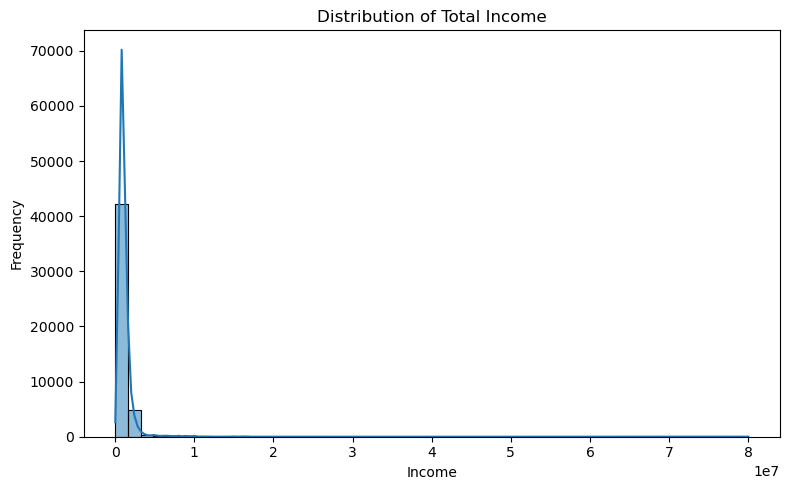

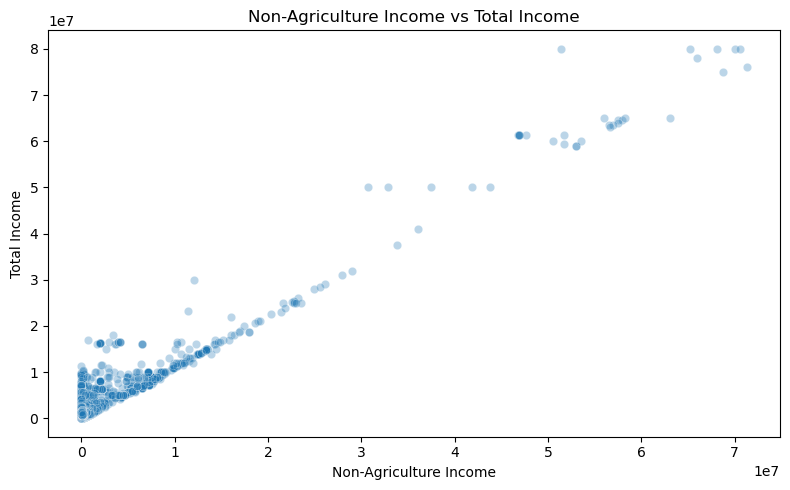

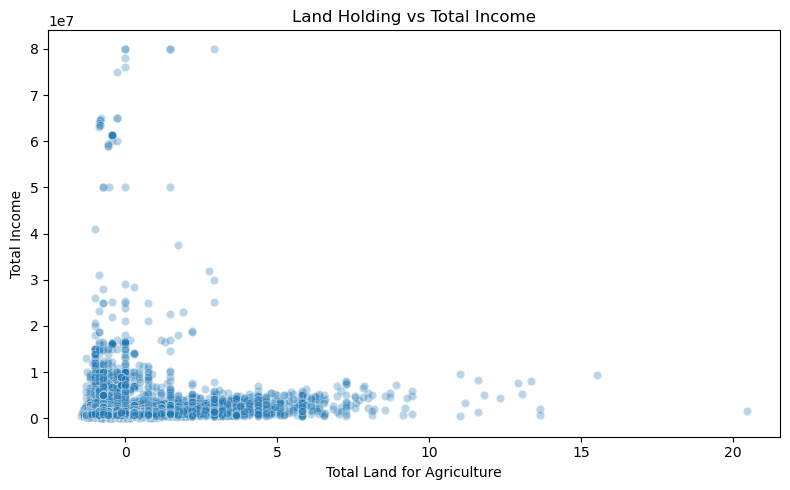

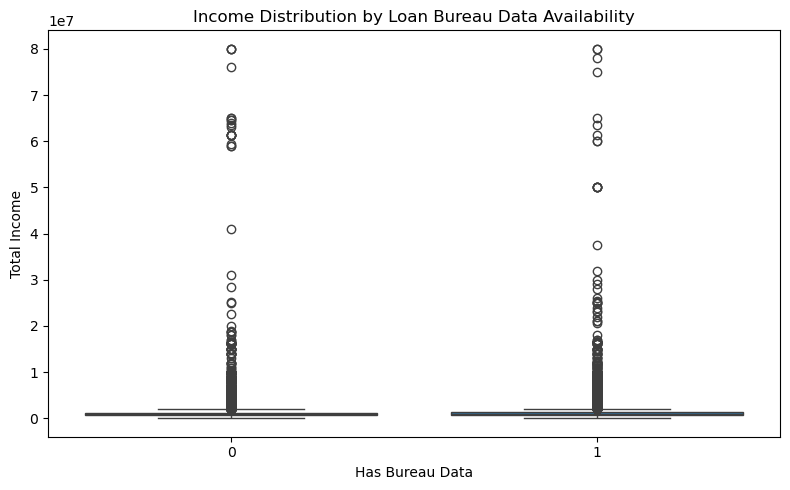

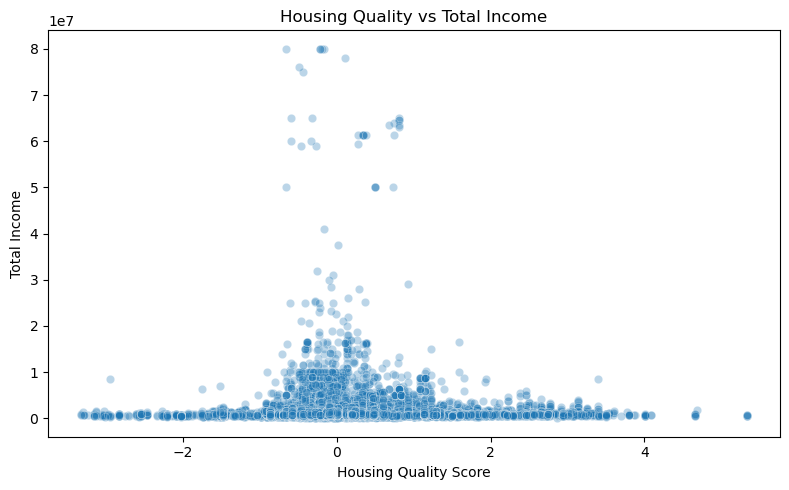

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample subset of engineered features for plotting
columns_to_plot = [
    'non_agriculture_income',
    'total_land_for_agriculture',
    'avg_disbursement_amount_bureau',
    'has_loan_bureau_data',
    'k022_seasonal_average_rainfall_mm',
    'perc_of_pop_living_in_hh_electricity',
    'mat_roof_metal_gi_asbestos_sheets',
    'housing_quality_score',
    'market_access_score',
    'agri_income_ratio',
    'target_variable_total_income'
]

# Load processed dataframe (assumes availability in context)
df = pd.read_csv(r"C:\Users\ak32a\Downloads\Anal-ysts\cleaned_dataset.csv")  # Replace with actual path if needed

# Plot 1: Distribution of Income
plt.figure(figsize=(8, 5))
sns.histplot(df['target_variable_total_income'], bins=50, kde=True)
plt.title("Distribution of Total Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Plot 2: Non-agriculture income vs Total Income
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='non_agriculture_income', y='target_variable_total_income', alpha=0.3)
plt.title("Non-Agriculture Income vs Total Income")
plt.xlabel("Non-Agriculture Income")
plt.ylabel("Total Income")
plt.tight_layout()
plt.show()

# Plot 3: Total Land vs Total Income
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='total_land_for_agriculture', y='target_variable_total_income', alpha=0.3)
plt.title("Land Holding vs Total Income")
plt.xlabel("Total Land for Agriculture")
plt.ylabel("Total Income")
plt.tight_layout()
plt.show()

# Plot 4: Average Disbursement Amount vs Income
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='has_loan_bureau_data', y='target_variable_total_income')
plt.title("Income Distribution by Loan Bureau Data Availability")
plt.xlabel("Has Bureau Data")
plt.ylabel("Total Income")
plt.tight_layout()
plt.show()

# Plot 5: Housing Quality Score vs Income
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='housing_quality_score', y='target_variable_total_income', alpha=0.3)
plt.title("Housing Quality vs Total Income")
plt.xlabel("Housing Quality Score")
plt.ylabel("Total Income")
plt.tight_layout()
plt.show()


In [71]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# ===============================
# STEP: Define Features & Target
# ===============================
X = df.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')
y = df['target_variable_total_income']

# ===============================
# STEP: Initialize Model
# ===============================
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# ===============================
# STEP: Cross-Validation
# ===============================
# MAE
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
mae_scores = cross_val_score(xgb_model, X, y, cv=5, scoring=mae_scorer)

# RMSE
rmse_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='neg_root_mean_squared_error')

# R²
r2_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')

# MAPE
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)
mape_scores = cross_val_score(xgb_model, X, y, cv=5, scoring=mape_scorer)

# ===============================
# STEP: Print Results
# ===============================
print("📊 Cross-Validation Results (5-Fold):")
print(f"Average MAE  : { -np.mean(mae_scores):,.2f}")
print(f"Average RMSE : { -np.mean(rmse_scores):,.2f}")
print(f"Average R²   : {  np.mean(r2_scores):.4f}")
print(f"Average MAPE : { -np.mean(mape_scores) * 100:.2f}%")


📊 Cross-Validation Results (5-Fold):
Average MAE  : 144,122.16
Average RMSE : 989,322.56
Average R²   : 0.7188
Average MAPE : 9.01%


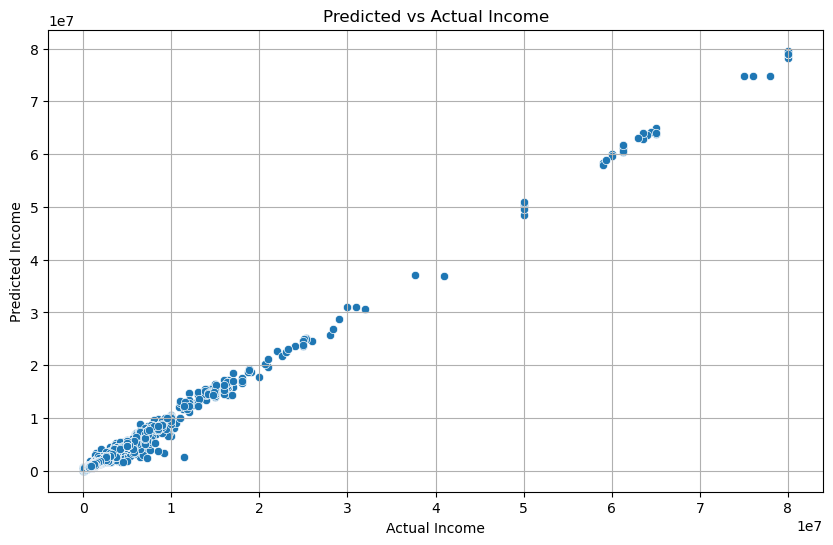

In [75]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split, cross_val_predict, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
)
from xgboost import XGBRegressor

# ========================================
# Outlier Investigation
# ========================================
X = df.drop(columns=['target_variable_total_income', 'farmerid'])
y = df['target_variable_total_income']

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X, y)
y_pred_full = xgb_model.predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=y_pred_full)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Predicted vs Actual Income")
plt.grid(True)
plt.show()

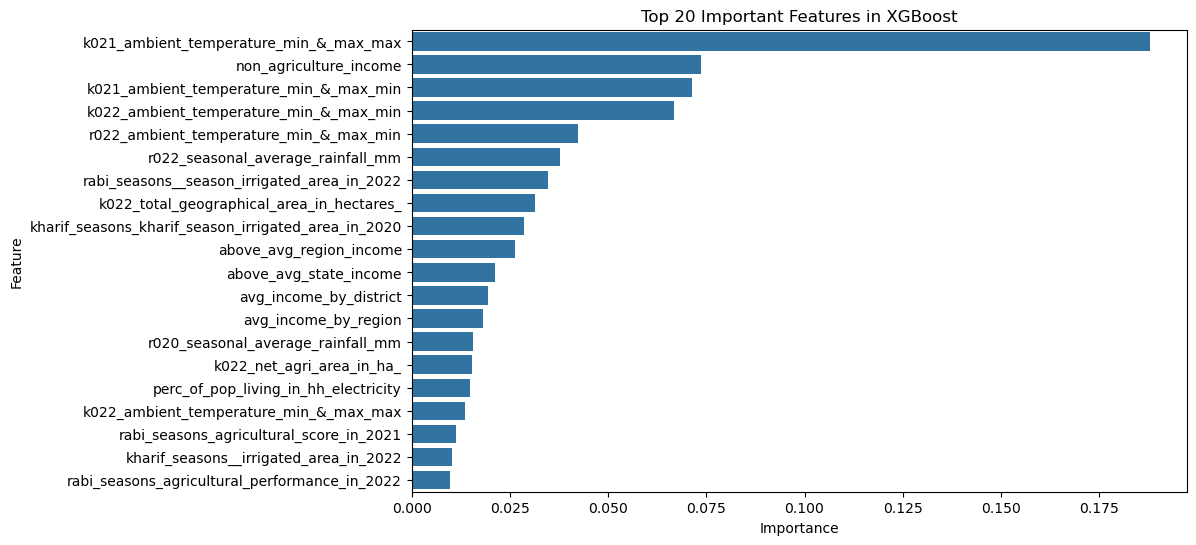

In [77]:
# ========================================
# Feature Importance
# ========================================
importances = xgb_model.feature_importances_
features = X.columns
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title("Top 20 Important Features in XGBoost")
plt.show()



In [79]:
# ========================================
# Log Transformation + Evaluation
# ========================================
y_log = np.log1p(y)
y_pred_log = cross_val_predict(xgb_model, X, y_log, cv=5)
y_pred_original = np.expm1(y_pred_log)

mae = mean_absolute_error(y, y_pred_original)
rmse = np.sqrt(mean_squared_error(y, y_pred_original))
r2 = r2_score(y, y_pred_original)
mape = mean_absolute_percentage_error(y, y_pred_original) * 100

print(f"MAE: ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")



MAE: ₹118,839.84
RMSE: ₹1,230,117.85
R² Score: 0.6482
MAPE: 5.85%


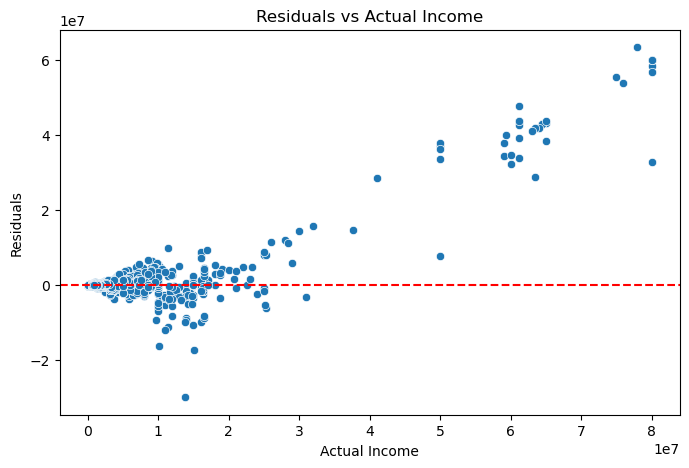

In [80]:
# ========================================
# Residual Analysis
# ========================================
residuals = y - y_pred_original
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Actual Income")
plt.xlabel("Actual Income")
plt.ylabel("Residuals")
plt.show()



In [83]:
# Error by bracket
df_eval = pd.DataFrame({'Actual': y, 'Predicted': y_pred_original})
df_eval['Income_Bracket'] = pd.cut(
    df_eval['Actual'],
    bins=[0, 1e6, 1e7, 2e7, 4e7, float('inf')],
    labels=['<1L', '1L–10L', '10L–20L', '20L–40L', '40L+']
)
bracket_errors = df_eval.groupby('Income_Bracket').apply(
    lambda x: mean_absolute_error(x['Actual'], x['Predicted'])
)
print("MAE by Income Bracket:\n", bracket_errors)

# ========================================
# Segmentation
# ========================================
df_low = df[df['target_variable_total_income'] < 1e6]
df_mid = df[(df['target_variable_total_income'] >= 1e6) & (df['target_variable_total_income'] <= 4e6)]
df_high = df[df['target_variable_total_income'] > 4e6]



MAE by Income Bracket:
 Income_Bracket
<1L        3.544865e+04
1L–10L     1.359357e+05
10L–20L    3.858514e+06
20L–40L    6.403286e+06
40L+       4.176178e+07
dtype: float64


C:\Users\ak32a\AppData\Local\Temp\ipykernel_24856\419066680.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bracket_errors = df_eval.groupby('Income_Bracket').apply(
C:\Users\ak32a\AppData\Local\Temp\ipykernel_24856\419066680.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bracket_errors = df_eval.groupby('Income_Bracket').apply(


In [85]:
# ========================================
# Tuning function with MAPE output
# ========================================
def tune_xgb_model(segment_df, segment_name):
    print(f"\n🔍 Tuning model for: {segment_name}")

    X = segment_df.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')
    y = segment_df['target_variable_total_income']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    }

    base_model = XGBRegressor(random_state=42, n_jobs=-1)

    search = RandomizedSearchCV(
        base_model,
        param_distributions=param_grid,
        n_iter=20,
        scoring='neg_mean_absolute_error',
        cv=3,
        verbose=0,  # Suppress spam
        random_state=42,
        n_jobs=-1,
        error_score='raise'
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    print(f"✅ Best Params: {search.best_params_}")
    print(f"MAE: ₹{mae:,.2f}")
    print(f"RMSE: ₹{rmse:,.2f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return best_model



In [87]:
# ========================================
# Train & Save tuned models
# ========================================
xgb_low = tune_xgb_model(df_low, 'Low Income')
xgb_mid = tune_xgb_model(df_mid, 'Mid Income')
xgb_high = tune_xgb_model(df_high, 'High Income')

joblib.dump(xgb_low, 'xgb_low_final.pkl')
joblib.dump(xgb_mid, 'xgb_mid_final.pkl')
joblib.dump(xgb_high, 'xgb_high_final.pkl')

print("\n✅ All models tuned & saved successfully.")



🔍 Tuning model for: Low Income
✅ Best Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
MAE: ₹10,018.08
RMSE: ₹23,729.64
R² Score: 0.9733
MAPE: 1.98%

🔍 Tuning model for: Mid Income
✅ Best Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
MAE: ₹27,452.10
RMSE: ₹69,505.24
R² Score: 0.9805
MAPE: 1.68%

🔍 Tuning model for: High Income
✅ Best Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
MAE: ₹817,038.50
RMSE: ₹1,857,957.00
R² Score: 0.9452
MAPE: 8.10%

✅ All models tuned & saved successfully.


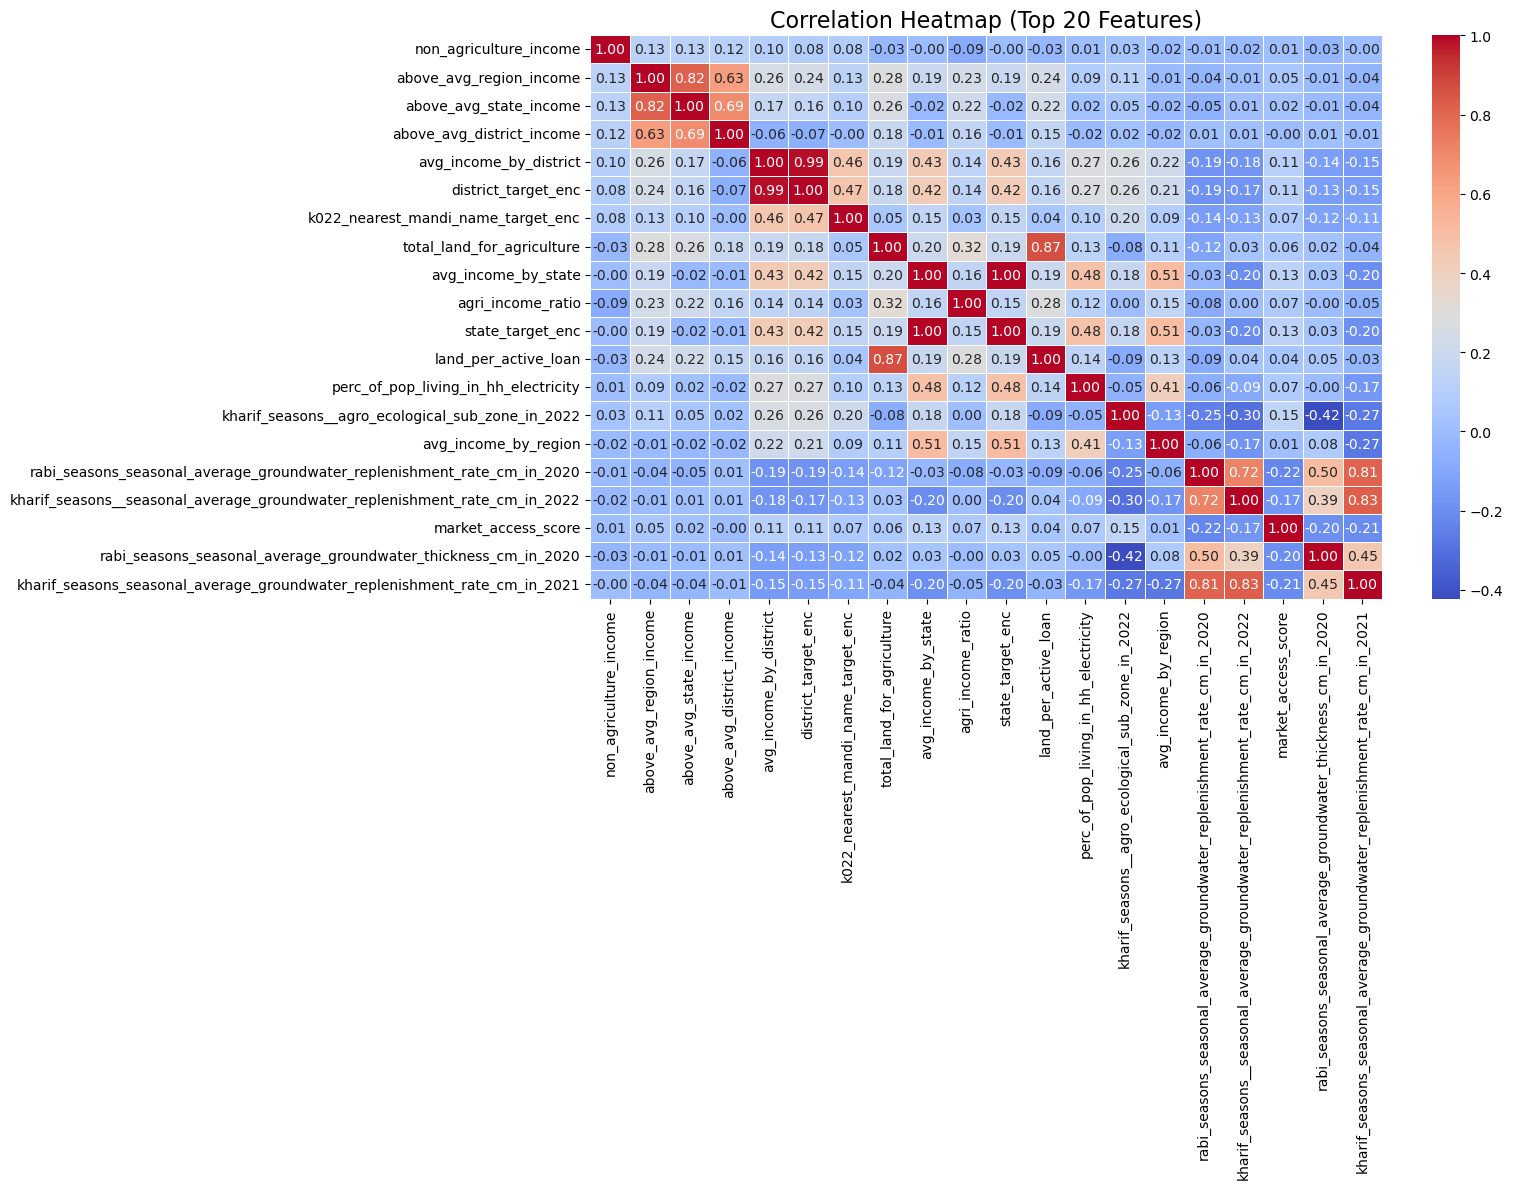

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# 2. Compute correlation matrix
corr_matrix = numeric_df.corr()

# 3. Select top N features most correlated with the target
target_corr = corr_matrix['target_variable_total_income'].abs().sort_values(ascending=False)
top_features = target_corr[1:21].index  # Exclude target itself and keep top 25

# 4. Filter correlation matrix to these features
filtered_corr = corr_matrix.loc[top_features, top_features]

# 5. Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(filtered_corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap (Top 20 Features)", fontsize=16)
plt.tight_layout()
plt.show()


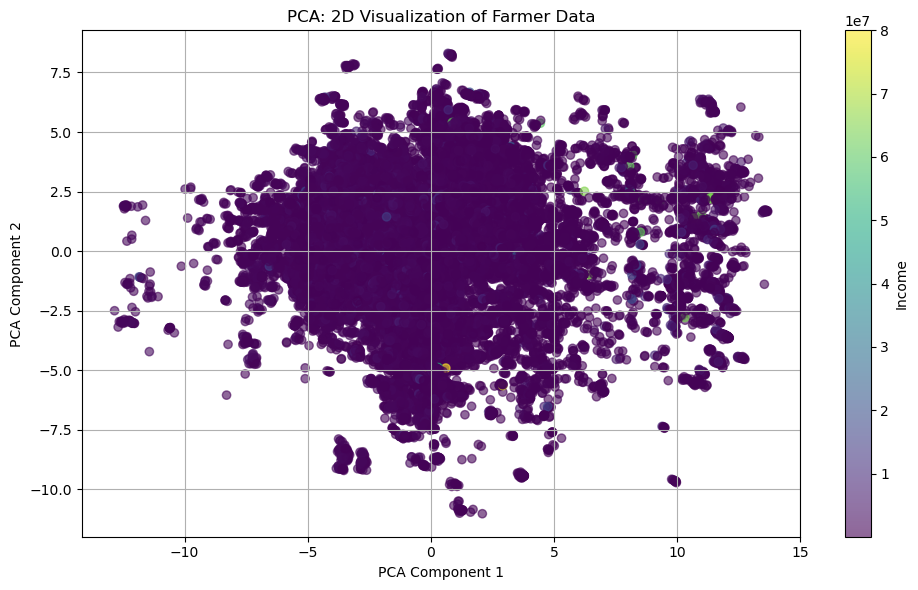

In [91]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Select only numeric features (excluding target + ID)
X_pca = df.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')
X_pca = X_pca.select_dtypes(include='number')

# 2. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# 3. Apply PCA
pca = PCA(n_components=2)
X_pca_components = pca.fit_transform(X_scaled)

# 4. Plot the PCA components
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_pca_components[:, 0],
    X_pca_components[:, 1],
    c=df['target_variable_total_income'],  # color by income
    cmap='viridis',
    alpha=0.6
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA: 2D Visualization of Farmer Data")
cbar = plt.colorbar(scatter)
cbar.set_label("Income")
plt.grid(True)
plt.tight_layout()
plt.show()


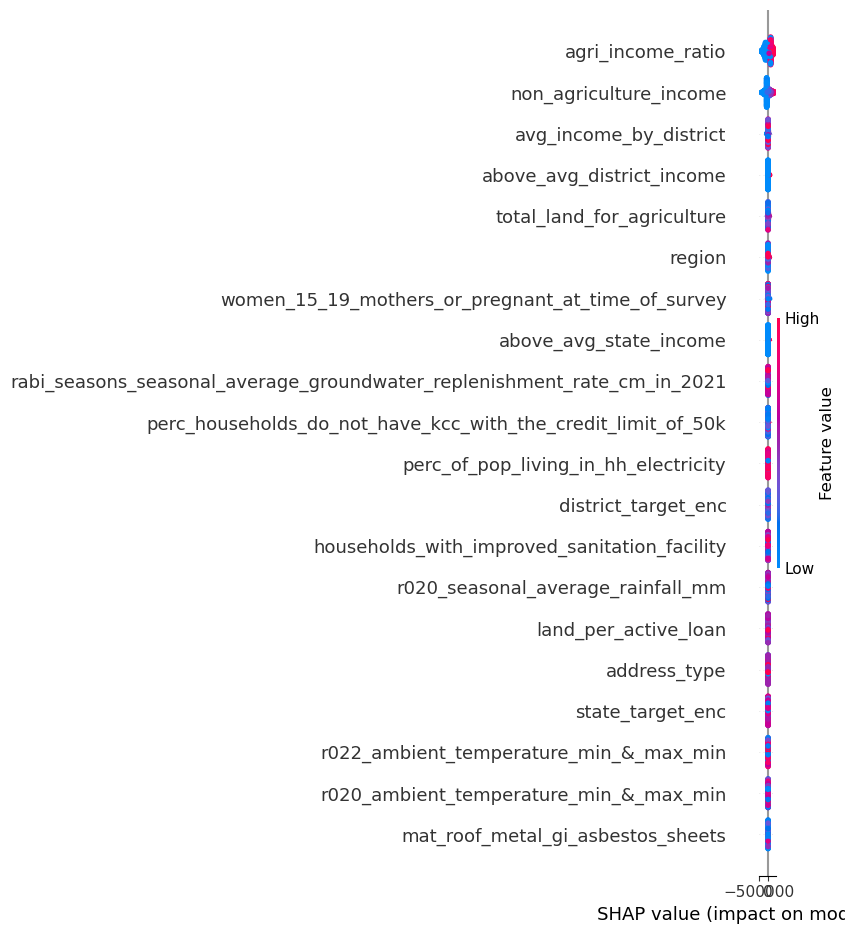

In [93]:
import shap

# Pick a trained model like xgb_low
model = xgb_low  # or xgb_mid / xgb_high

# Features used to train that segment
X_segment = df_low.drop(columns=['target_variable_total_income', 'farmerid'], errors='ignore')

# Sample data for speed
X_sample = X_segment.sample(n=1000, random_state=42)

# Init SHAP
shap.initjs()

# TreeExplainer for XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Plot summary
shap.summary_plot(shap_values, X_sample)


In [ ]:
# Finally it worked, after so many erros.

In [171]:
# ====================================================
# STEP 0: Imports
# ====================================================
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder

# ====================================================
# STEP 1: Load Models & Artifacts
# ====================================================
TEST_FILE = r"C:\Users\ak32a\Downloads\Anal-ysts\LTF Challenge data with dictionary.xlsx"
MODEL_FILES = {
    'low': "xgb_low_final.pkl",
    'mid': "xgb_mid_final.pkl",
    'high': "xgb_high_final.pkl"
}
TARGET_MAPS_FILE = "target_maps.pkl"
FEATURE_COLUMNS_FILE = "feature_columns.pkl"

# Load models
models = {seg: joblib.load(path) for seg, path in MODEL_FILES.items()}

# Load target encoding maps & feature columns
target_maps = joblib.load(TARGET_MAPS_FILE)
feature_columns = joblib.load(FEATURE_COLUMNS_FILE)

# ====================================================
# STEP 2: Utility Functions
# ====================================================
def clean_column(col_name):
    return (
        col_name.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

def safe_split_temp_cols(df, temp_cols):
    for col in temp_cols:
        if col in df.columns:
            df[[f"{col}_min", f"{col}_max"]] = df[col].astype(str).str.split('/', expand=True).astype(float)
    df.drop(columns=[c for c in temp_cols if c in df.columns], inplace=True)

# On-the-fly label encoding (no pickle file needed)
label_cols = [
    'region', 'sex', 'marital_status', 'address_type', 
    'ownership', 'kharif_seasons__agro_ecological_sub_zone_in_2022',
    'kharif_seasons_type_of_soil_in_2021'
]
def encode_labels_on_the_fly(df):
    for col in label_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = df[col].fillna("Unknown").astype(str)
            df[col] = le.fit_transform(df[col])
    return df

def target_encode(df):
    for col, mapping in target_maps.items():
        if col in df.columns:
            df[col + '_target_enc'] = df[col].map(mapping).fillna(np.mean(list(mapping.values())))
    return df

# ====================================================
# STEP 3: Preprocessing
# ====================================================
def preprocess(df):
    df = df.copy()

    # 1️⃣ Clean column names
    df.columns = [clean_column(c) for c in df.columns]

    # 2️⃣ Basic missing handling
    df.fillna(0, inplace=True)

    # 3️⃣ Water body keywords
    water_col = next((c for c in df.columns if "type_of_water_bodies" in c), None)
    if water_col:
        df[water_col] = df[water_col].astype(str).str.lower()
        for kw in ['river', 'water', 'reservoir', 'riverbank', 'wetland']:
            df[f'near_{kw}'] = df[water_col].apply(lambda x: int(kw in x))
        df.drop(columns=[water_col], inplace=True)

    # 4️⃣ Split temperature cols
    temp_cols = [
        'k022_ambient_temperature_min_&_max',
        'r022_ambient_temperature_min_&_max',
        'k021_ambient_temperature_min_&_max',
        'r021_ambient_temperature_min_&_max',
        'r020_ambient_temperature_min_&_max'
    ]
    safe_split_temp_cols(df, temp_cols)

    # 5️⃣ Domain features
    if 'total_land_for_agriculture' in df.columns and 'no_of_active_loan_in_bureau' in df.columns:
        df['land_per_active_loan'] = df['total_land_for_agriculture'] / (df['no_of_active_loan_in_bureau'] + 1)

    if 'target_variable_total_income' in df.columns and 'non_agriculture_income' in df.columns:
        df['agri_income_ratio'] = df['target_variable_total_income'] / (df['non_agriculture_income'] + 1)

    rain_cols = [c for c in df.columns if 'rainfall_mm' in c]
    if rain_cols:
        df['avg_rainfall'] = df[rain_cols].mean(axis=1)

    living_cols = [
        'perc_of_house_with_6plus_room',
        'perc_households_with_pucca_house_that_has_more_than_3_rooms',
        'perc_of_pop_living_in_hh_electricity'
    ]
    if all(c in df.columns for c in living_cols):
        df['housing_quality_score'] = df[living_cols].mean(axis=1)

    gw_cols = [c for c in df.columns if 'groundwater_thickness' in c]
    if gw_cols:
        df['groundwater_variability'] = df[gw_cols].std(axis=1)

    if 'k022_proximity_to_nearest_mandi_km' in df.columns:
        df['market_access_score'] = 1 / (df['k022_proximity_to_nearest_mandi_km'] + 1)
    if 'k022_proximity_to_nearest_railway_km' in df.columns:
        df['rail_access_score'] = 1 / (df['k022_proximity_to_nearest_railway_km'] + 1)

    # 6️⃣ Encode labels ON THE FLY
    df = encode_labels_on_the_fly(df)

    # 7️⃣ Target encoding
    df = target_encode(df)

    # 8️⃣ Ensure required engineered columns exist
    expected_extra_cols = [
        'above_avg_district_income', 'above_avg_state_income', 'avg_income_by_district', 'avg_income_by_state',
        'above_avg_region_income', 'avg_income_by_region', 'has_loan_bureau_data'
    ]
    for col in expected_extra_cols:
        if col not in df.columns:
            df[col] = 0

    # 9️⃣ Final cleanup
    df.drop(columns=['district', 'state', 'k022_nearest_mandi_name'], errors='ignore', inplace=True)

    return df

# ====================================================
# STEP 4: Segment & Predict
# ====================================================
def segment_and_predict(df_test_raw):
    df_processed = preprocess(df_test_raw)
    df_pred = df_test_raw.copy()

    # Assign segments
    df_processed['segment'] = 'mid'
    if 'total_land_for_agriculture' in df_processed.columns:
        df_processed.loc[df_processed['total_land_for_agriculture'] < 2, 'segment'] = 'low'
        df_processed.loc[df_processed['total_land_for_agriculture'] > 6, 'segment'] = 'high'

    # Predict per segment
    for seg, model in models.items():
        seg_df = df_processed[df_processed['segment'] == seg]
        if not seg_df.empty:
            X = seg_df[[c for c in feature_columns if c in seg_df.columns]]
            preds = model.predict(X)
            df_pred.loc[seg_df.index, 'Predicted_Income'] = preds

    return df_pred

# ====================================================
# STEP 5: Load Test Data & Run
# ====================================================
df_test = pd.read_excel(TEST_FILE, sheet_name="TestData")
df_with_preds = segment_and_predict(df_test)

print(df_with_preds.head())
df_with_preds.to_csv("test_predictions.csv", index=False)
print("✅ Predictions saved to test_predictions.csv")


           FarmerID      State REGION SEX      CITY  Zipcode   DISTRICT  \
0   576972022499073  KARNATAKA  SOUTH   M  TUMAKURU   572102     TUMKUR   
1   979235081831136    HARYANA  NORTH   M     KALKA   133302  PANCHKULA   
2   176490610549774    HARYANA  NORTH   M   PINJORE   134102  PANCHKULA   
3   977021407171384    HARYANA  NORTH   M   PINJORE   134102  PANCHKULA   
4  1334154133262320    HARYANA  NORTH   M   PINJORE   134102  PANCHKULA   

  VILLAGE MARITAL_STATUS               Location  ...  \
0  Tumkur              M  13.3173175,77.1240408  ...   
1   Kalka              M  30.4749107,77.1320795  ...   
2   Kalka              M                    NaN  ...   
3   Kalka              S                    NaN  ...   
4   Kalka              M  30.7982131,76.9209035  ...   

  Rabi Seasons Seasonal average groundwater thickness (cm) in 2020  \
0                                              92.35                 
1                                              43.91                 
2 